In [ ]:
# pyGAM is not preinstalled in Colab
%pip install -q pygam


Note: you may need to restart the kernel to use updated packages.


# **GLM and GAM: interpretation on the right scale**

### A tutorial — practice for the lessons "Logistic regression" and "GLM, GAM"

Welcome to this overview tutorial on using linear models that work in different setups!

Here we will:
- go step by step through how the interpretation of the weights changes on a different scale;
- look at the possible gain from moving from a linear model to a GLM or a GAM.

In short, we will get hands-on with all the theory you have already read in the lessons.

What awaits us:

1. **GLM with three distributions** — Bernoulli/logit (classification), Poisson/log (count data), Gamma/log (a skewed positive quantity);
2. **GAM**;
3. **An implementation of GAMI-Net**.

## Block 1. GLM
### 1 — Logistic regression (Bernoulli/logit)

As we saw in the lessons, logistic regression is the basic special case of a Generalized Linear Model: $\text{logit}(p)=\log\frac{p}{1-p}=\beta_0+\sum_j\beta_jx_j$.

Let us recall and keep in front of us that the ratio $\frac{p}{1-p}$ is called the odds. In the lessons we derived two relations:

1. If we take a feature $x_j$ with weight $\beta_j$ and change the value of the feature by a number $k$, we get

    $$odds_{new}=e^{\beta_0+\dots+\beta_j(x_j+k)+\dots+\beta_nx_n}=e^{k\beta_j}\cdot e^{\beta_0+\dots+\beta_jx_j+\dots+\beta_nx_n}$$

    That is,
    $$\frac{odds_{new}}{odds_{old}}=e^{k\beta_j}$$

2. If we take a feature $x_j$ with weight $\beta_j$ and change the value of the weight to a number $\beta_j'$, we get

    $$odds_{new}=e^{\beta_0+\dots+\beta_j'x_j+\dots+\beta_nx_n}=e^{(\beta_j'-\beta_j)x_j}\cdot e^{\beta_0+\dots+\beta_jx_j+\dots+\beta_nx_n}.$$

    Whence
    $$\frac{odds_{new}}{odds_{old}}=e^{x_j(\beta_j'-\beta_j)}.$$

In the lessons of this module we said that a change in the odds is not equal in strength to a change in the probability. Let us take a look at that!

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

First let us train a model and look at the weights. 

In [ ]:
path = 'https://github.com/SadSabrina/interpretable_AI_course/raw/refs/heads/main/data/diabetes.csv'
data = pd.read_csv(path)

train_data, test_data = train_test_split(data, test_size=0.25, random_state=42)
X_train, y_train = train_data.drop('Outcome', axis=1), train_data['Outcome']
X_test, y_test = test_data.drop('Outcome', axis=1), test_data['Outcome']

sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_sc, y_train)

coefs = pd.Series(logreg.coef_[0], index=X_train.columns).sort_values(key=abs, ascending=False)
coefs.round(4)

Glucose                     1.1312
BMI                         0.7601
Age                         0.4299
BloodPressure              -0.2224
Pregnancies                 0.2017
Insulin                    -0.1725
DiabetesPedigreeFunction    0.1718
SkinThickness               0.0661
dtype: float64

The largest weight belongs to the `Glucose` feature, and that even matches the real world. The glucose level is one of the main predictors of diabetes. An elevated sugar level indicates a risk of developing the disease — the same holds for our weights, and the higher the value, the stronger the contribution to the final prediction.

Let us concentrate on the relation weight $\leftrightarrow$ model prediction. 

### **What we get in the weights.**

In ML libraries the final logistic regression algorithm most often predicts a `class` by default.

- In Python (sklearn, scipy) you can move from a class prediction to probabilities using `lr.predict_proba(X_test)`. You can also work with the odds (log-odds) using `lr.decision_function(X_test)`.

- In R — also one of the popular languages for statistical modelling — probabilities are returned by default. For several years that language was the standard (around 2021), which is why we give it as an example. By the way, in R the very same model is built through `glm()`.

```r
model <- glm(Outcome ~ ., data = train_data, family = binomial(link = "logit"))

# probabilities P(Y=1)
p_hat <- predict(model, newdata = test_data, type = "response")

# log-odds (the same z as decision_function in sklearn)
z_hat <- predict(model, newdata = test_data, type = "link")
```

Since we work in Python, let us go back to sklearn. Our LogisticRegression predicts probabilities, which are binarized if you use the `predict` method and returned raw in the order `P(Y=0), P(Y=1)` if you use `predict_proba`.

Hence, without the out-of-the-box methods the prediction is given exactly by the formula $\text{logit}(p)=\log\frac{p}{1-p}=\beta_0+\sum_j\beta_jx_j$. 

In [ ]:
# log_odds = logreg.decision_function(X_test)

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# let us check this 

np.all(sigmoid(logreg.intercept_ + X_test_sc @ logreg.coef_[0]) == logreg.predict_proba(X_test_sc)[:, 1])

True

Let us look at how the growth of the **weight** and the growth of the **feature** separately translate into a change of the probability. We will run two experiments.  

### Experiment 1 — the feature grows, the weight is fixed.

Consider a typical patient whose features all equal the mean value. Since we standardized the data above, the mean over the features is zero for us. Hence we will change the prediction from the formula:

$$\text{logit}(p)=\log\frac{p}{1-p} = \beta_0 + \sum_{j} \beta_j x_j = \beta_0 + \beta_{Glucose}\cdot x_{Glucose} + \underbrace{\sum_{j \neq Glucose} \beta_j \cdot 0}_{=\,0} =$$
$$ = \beta_0 + \beta_{Glucose}\cdot x_{Glucose}$$

Then a shift of the feature by $k$:

$$\text{logit}(p)_{new}=\log\frac{p}{1-p} = \beta_0 + \beta_{Glucose}\cdot(x_{Glucose}+k)$$

and we look at how that changes the probability $p=\dfrac{1}{1+e^{-\text{logit}(p)}}$.

Since the data is standardized, we will also need to bring Glucose back to the standardized distribution in order to make meaningful interventions in the numbers. 

In [ ]:

print(sc.feature_names_in_) # glucose has index 1
glu_mean = sc.mean_[1]
glu_std = np.sqrt(sc.var_[1])

print(f'Raw glucose mean = {glu_mean}, raw glucose std = {glu_std}')

['Pregnancies' 'Glucose' 'BloodPressure' 'SkinThickness' 'Insulin' 'BMI'
 'DiabetesPedigreeFunction' 'Age']
Raw glucose mean = 120.65972222222223, raw glucose std = 32.10527673712351


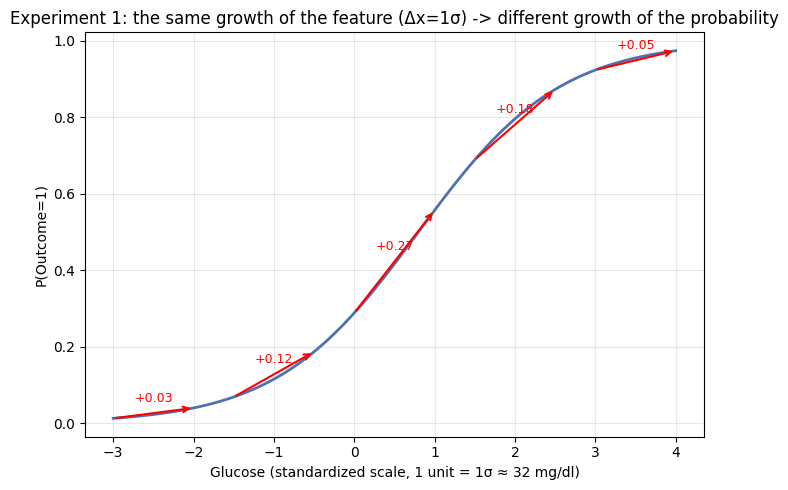

In [ ]:
def scale_number(x, mean, std):
    return (x - mean) / std

w_glucose = coefs['Glucose']
b0 = logreg.intercept_[0]

chances_change = []
glu_grid = np.linspace(glu_mean - 3*glu_std, glu_mean + 4*glu_std, 200)
glu_grid_scaled = scale_number(glu_grid, glu_mean, glu_std)

p_grid = 1 / (1 + np.exp(-(b0 + w_glucose * glu_grid_scaled)))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(glu_grid_scaled, p_grid, color='#4C72B0', lw=2)

for init_value in [glu_mean - 3*glu_std, glu_mean - 3*glu_std/2, glu_mean, glu_mean + 3*glu_std/2, glu_mean + 3*glu_std]:

    z0 = scale_number(init_value, glu_mean, glu_std) # initial point (raw)
    x0 = b0 + w_glucose * z0 #  chances on initial point
    p0 = 1 / (1 + np.exp(-(x0))) # proba on initial point


    # a shift of 1σ in the original Glucose units is exactly Δz=1 on the standardized scale
    z1 = scale_number(init_value + glu_std, glu_mean, glu_std) # step from initial point 

    x1 = b0 + w_glucose * z1 # chances after step from initial point 
    p1 = 1 / (1 + np.exp(-(x1))) # proba after step from initial point 

    chances_change.append(x1 - x0)

    ax.annotate('', xy=(z0 + 1, p1), xytext=(z0, p0), arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
    ax.text(z0 + 0.5, (p0 + p1) / 2 + 0.03, f'+{p1 - p0:.2f}', color='red', fontsize=9, ha='center')

ax.set_xlabel('Glucose (standardized scale, 1 unit = 1σ ≈ 32 mg/dl)')
ax.set_ylabel('P(Outcome=1)')
ax.set_title('Experiment 1: the same growth of the feature (Δx=1σ) -> different growth of the probability')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# let us make sure the change in odds was constant
chances_change

[1.1311545871945965,
 1.1311545871945956,
 1.131154587194596,
 1.1311545871945958,
 1.1311545871945956]

**What we observe:** the same step of the feature $\Delta x=1\sigma$ and the same change of the odds 1.13$ gives an increase of the probability of $+0.12$ around $z=-1$, growing to $+0.27$ around $z=0$. After that the increase falls again — first to $+0.13$ around $z=2$, and then to +0.05.

This observation will hold **the same way for any patient** — the shift $\Delta z=k\beta_j$ does not depend on what particular value of the feature the patient had before; the zeros only simplified our code.

Now let us look at the growth of the weight at a fixed value of the feature. 

### Experiment 2 — the weight grows, the feature is fixed.

Consider the same Glucose feature. A close look at the formula $\Delta z=x_j(\beta_j'-\beta_j)$ lets us notice that the shift of $z$ is proportional to **the value of the feature for the particular patient**. If a patient has $x_j=0$ (for example, the same Glucose exactly at the sample mean level), then the multiplier is zero, and it does not matter how much the weight changes: $\Delta z$ will still be 0.

That is why we will not consider only the average patient, but a range of possible patients as the **relative contribution of the weight changes from 0 to 100**. Considering the weight itself is not as productive — it always takes up some "mass" from the others.  

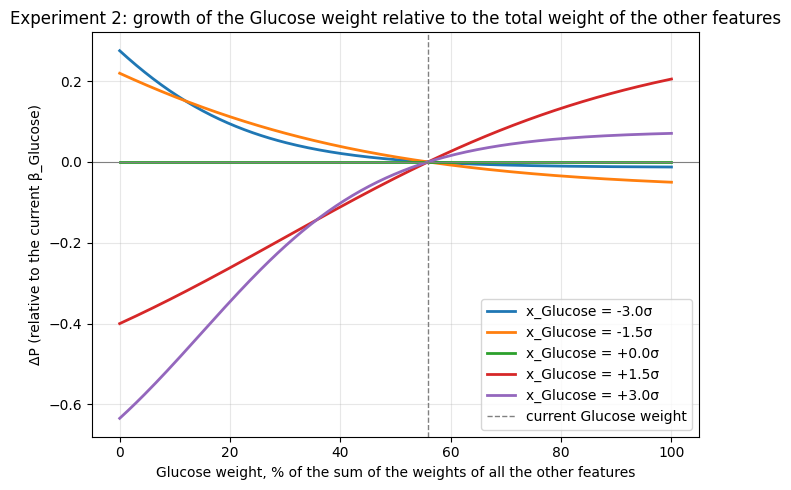

In [ ]:
# the total weight of all the OTHER features (by absolute value) — this is "everything else taken together"
w_others_sum = coefs.drop('Glucose').abs().sum()

# the relative contribution of the Glucose weight: from 0% (weight=0) to 100% (the Glucose weight equals the sum of all the others)
rel_share = np.linspace(0, 1, 200)
w_grid = rel_share * w_others_sum

patient_z_values = [-3, -1.5, 0,  1.5, 3]  # on the standardized scale (units of σ)

fig, ax = plt.subplots(figsize=(7, 5))

for z_patient in patient_z_values:
    p_old = 1 / (1 + np.exp(-(b0 + w_glucose * z_patient)))
    p_new_grid = 1 / (1 + np.exp(-(b0 + w_grid * z_patient)))
    delta_p_grid = p_new_grid - p_old
    ax.plot(rel_share * 100, delta_p_grid, lw=2, label=f'x_Glucose = {z_patient:+.1f}σ')

ax.axvline(w_glucose / w_others_sum * 100, color='gray', ls='--', lw=1, label='current Glucose weight')
ax.axhline(0, color='gray', lw=0.8)
ax.set_xlabel('Glucose weight, % of the sum of the weights of all the other features')
ax.set_ylabel('ΔP (relative to the current β_Glucose)')
ax.set_title('Experiment 2: growth of the Glucose weight relative to the total weight of the other features')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**What we observe:**

First, the direction of the probability shift depends on the **sign** of $x_j$ for the patient. For patients with elevated glucose ($+1.5\sigma$, $+3\sigma$) the growth of the weight raises the probability — the lines go up to the right of the intersection point; for patients with lowered glucose ($-1.5\sigma$, $-3\sigma$) it lowers it, the lines go down.

Second, the magnitude of the effect is not proportional to $|x_j|$ but depends on where the feature starts relative to the steep part of the sigmoid.
-  the typical patient, thanks to the standardization of the data, has a feature equal to 0 and loses and gains nothing when the weight changes.
 - the patient whose glucose value was initially large ($+3\sigma$) loses **the most** if the weight is zeroed from its current value ($\Delta P\approx-0.63$). But under further growth of the weight that same patient gains **the least** ($\Delta P\approx+0.07$ at the right edge).
- the patient with the value $+1.5\sigma$ got the strongest increase when the weight grew from its current value ($\Delta P\approx+0.21$). Their starting point is not saturated but closer to the steep middle of the sigmoid, so they react more strongly than the "extreme" patient at $+3\sigma$.
- for patients with a low glucose level the probability grows noticeably when the weight decreases ($\Delta P\approx+0.22$ for $-1.5\sigma$), but drops only slightly under further growth of the weight ($\Delta P\approx-0.05$) — the same asymmetry due to the saturation of the sigmoid, only from the other side.

In sum, we see that here the sensitivity of the quantity we care about — the probability — to both a shift of the feature and a shift of the weight depends not on $x_j$ or $\beta_j$ separately, but on where the resulting $z=\beta_0+\sum_j\beta_jx_j$ lands on the sigmoid curve. A central value amplifies the shift, the saturated edges damp almost any shift. So in practice we see our theoretical thesis — the weights must be interpreted together with the link function.

## Block 2. GLM #2 — Poisson (count data)

The second member of the GLM family is Poisson regression for data interpreted as a number of events per interval. The link function here has the form:

$$ \log(\mathbb{E}[Y|X])=\beta_0+\sum_j \beta_j x_j $$

And from the lessons we know that to analyse the weights of a Poisson regression one uses the **IRR** (incidence rate ratio), the ratio of intensities: how many times the expected number of events $μ$ changes when the feature increases by $1$. The formula: for a feature $x_j: IRR =e(w_j)$ (for a shift of $Δx: e(w_jΔx)$). A value $>1$ means a growth of the intensity, $<1$ a fall.

Let us see it in action on the school performance dataset `student-mat.csv` and the feature `absences` — the number of missed classes. To build a Poisson regression we will need the `statsmodels` library.

**Why not sklearn?**
sklearn formally has a `PoissonRegressor` — it gives point estimates of the coefficients and a prediction, but does not compute standard errors, confidence intervals and p-values. In the block on logistic regression we saw how non-trivial the analysis of coefficients is, and now we will cheat a little — we will analyse significance using the statistical machinery of `statsmodels`. Along the way we will probe the limits of that trick.

**A reminder.** A p-value is the probability of obtaining the observed or an even more extreme (in the sense of the null hypothesis) estimate in an experiment, assuming that the effect being tested is random (that is, the so-called null hypothesis is true). In our case it is the probability of getting a non-zero coefficient given that there is in fact no true effect. If that probability is small (we will consider $p<0.05$), then under the given assumptions of the model it is unlikely to get such a non-zero weight if the feature were not actually related to the target (with the other features fixed).

The important words here are "under the given assumptions of the model". Around any statistical test there are always the conditions of the model. Here the p-value is computed via the t-statistic $t=\hat\beta_j/SE(\hat\beta_j)$, and $SE$ depends directly on how correctly the model describes the variance of the data. If the assumption about the variance is wrong, the whole significance calculation runs on a skewed scale — even if the point estimate $\hat\beta_j$ itself stayed the same. We will need this when analysing the results.

In [ ]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

data_students = pd.read_csv('https://github.com/SadSabrina/open-xai-materials/raw/refs/heads/main/data/student-mat.csv', sep=';')

model_poisson = smf.glm('absences ~ studytime + health + goout + failures', data=data_students, family=sm.families.Poisson()).fit()

irr = np.exp(model_poisson.params)
ci = model_poisson.conf_int()

irr_table = pd.DataFrame({
    'IRR': irr.round(3),
    'IRR_low': np.exp(ci[0]).round(3),
    'IRR_high': np.exp(ci[1]).round(3),
    'p_value': model_poisson.pvalues.round(4),
    'p_value < 0.05': model_poisson.pvalues.round(4) < 0.05,
})
irr_table

,IRR,IRR_low,IRR_high,p_value,p_value < 0.05
Intercept,6.669,5.461,8.144,0.0000,True
studytime,0.911,0.865,0.959,0.0004,True
health,0.964,0.936,0.992,0.0138,True
goout,1.042,1.004,1.082,0.0288,True
failures,1.091,1.036,1.149,0.0010,True


**What we observe:**
- All the effects are significant.
- every additional unit of `studytime` is associated with a reduction of the expected number of absences by $\approx 9\%$ (IRR $\approx 0.91$),
- `health` reduces absences by $\approx 4\%$,
- every past `failures` is associated with a growth of $\approx 9\%$ (IRR $\approx 1.09$);
- `goout` increases absences by $\approx 4\%$


Excellent. On the one hand, at this stage we got an impressive statistical analysis out of the box. However, here, as with any result, we have to make sure that we can trust such significance. 

**A good tool is good within the environment it was made for.**

Like any tool, the p-value has an important particularity: it is correct only when the assumptions of the model hold.

In Poisson regression the significance of the coefficients is computed through the standard error:

$$t=\frac{\hat\beta}{SE(\hat\beta)}$$

The coefficient $\hat\beta$ itself is estimated from the data, while the standard error is computed from the assumptions of the model. One of the main Poisson assumptions is

$\operatorname{Var}(Y)=\mathbb E[Y].$

If the data is noisy and goes beyond the assumptions of the model (this is called overdispersion), the model underestimates the standard errors. Then an unpleasant chain arises:

* the model understates SE;
* because of that the t-statistic becomes too large;
* and the p-value too small.

The result is a false confidence that the effect is statistically significant. In our data this is exactly the case: the mean is ≈ 5 while the variance is ≈ 64. That is about 11 times more than expected. If the difference came down only to the scale of the variance, the standard errors should have increased by about $\sqrt{11.2}\approx3.35$ times and affected the p-value.

To test this hypothesis, let us build a Negative Binomial model. It uses the same logarithmic link function ($\log(\mathbb E[Y|X])=\beta_0+\sum_j\beta_jx_j$),

but differs in a different assumption about the distribution of the response. Instead of requiring the variance to equal the expectation, the Negative Binomial model allows the variance to be larger than the mean:

$$\operatorname{Var}(Y)=\mu+\alpha\mu^2,$$

where the parameter $\alpha>0$ is estimated from the data and determines the degree of overdispersion.

If the reason really is overdispersion, then the coefficients of the model themselves should stay close to the Poisson regression estimates — after all, both models describe the same dependence between the features and the target variable. The standard errors and p-values, on the other hand, may change quite substantially, since they will now be computed under a more realistic assumption about the variance of the data.

In [ ]:
dispersion_ratio = data_students['absences'].var() / data_students['absences'].mean()
print('mean(absences) = %.2f,  var(absences) = %.2f' % (data_students['absences'].mean(), data_students['absences'].var()))
print('Var/Mean(absences):', round(dispersion_ratio, 2), '(for Poisson we expect ~1)')

model_nb = smf.glm('absences ~ studytime + health + goout + failures', data=data_students, family=sm.families.NegativeBinomial()).fit()

irr_nb = np.exp(model_nb.params)
comparison_glm = pd.DataFrame({
    'IRR_Poisson': irr.round(3),
    'p_Poisson': model_poisson.pvalues.round(3),
    'p_sign_Poisson': model_poisson.pvalues.round(3) < 0.05,
    'IRR_NegBinom': irr_nb.round(3),
    'p_NegBinom': model_nb.pvalues.round(3),
    'p_sign_NegBinom': model_nb.pvalues.round(3) < 0.05,
})
comparison_glm

mean(absences) = 5.71,  var(absences) = 64.05
Var/Mean(absences): 11.22 (for Poisson we expect ~1)


,IRR_Poisson,p_Poisson,p_sign_Poisson,IRR_NegBinom,p_NegBinom,p_sign_NegBinom
Intercept,6.669,0.000,True,6.738,0.000,True
studytime,0.911,0.000,True,0.902,0.122,False
health,0.964,0.014,True,0.970,0.433,False
goout,1.042,0.029,True,1.035,0.486,False
failures,1.091,0.001,True,1.120,0.127,False


Which is what we set out to show — we see that the weights are close, but the p-values differ for all the features except one. 

In [ ]:
se_compare = pd.DataFrame({
    'SE_Poisson': model_poisson.bse.round(4),
    'SE_NegBinom': model_nb.bse.round(4),
    'how many times wider (NB/Poisson)': (model_nb.bse / model_poisson.bse).round(2),
})
se_compare

,SE_Poisson,SE_NegBinom,how many times wider (NB/Poisson)
Intercept,0.1019,0.2652,2.60
studytime,0.0265,0.0667,2.52
health,0.0150,0.0394,2.62
goout,0.0189,0.0495,2.61
failures,0.0265,0.0741,2.80


**Conclusion: before trusting significance in a GLM, always check whether the chosen distribution fits the data** (`Var/Mean` for Poisson is the cheapest of such checks).

Let us move on to the third type of regression.

**For the curious. What has the standard error got to do with it at all?**

The coefficients of a GLM are estimated by maximum likelihood estimation (MLE). For MLE there is a fundamental result of mathematical statistics: for a large enough sample size the estimate of the parameters has an approximately normal distribution

$$\hat\beta \overset{approx}{\sim} N \left(\beta, I(\beta)^{-1}\right)$$

where $I(\beta)$ is the Fisher information matrix. Therefore the standard error of every coefficient is the square root of the corresponding diagonal element of the matrix $I(\beta)^{-1}$.

Intuitively, the Fisher information measures how sharp the maximum of the likelihood function turned out to be. If the maximum is narrow and steep, the parameters are determined fairly precisely — the standard errors are small. If the maximum is "flat", there are many almost equally good values of the parameters, so the uncertainty grows, and with it the standard errors.

For an ordinary linear regression this general theory reduces to the familiar formula
$$\operatorname{Var}(\hat\beta)=\sigma^2(X^TX)^{-1}$$

where $\sigma^2$ is the variance of the noise and the matrix $(X^TX)^{-1}$ depends only on the features.

From this follows one more consequence already familiar to us. If the features correlate strongly with each other (multicollinearity), the diagonal elements of $(X^TX)^{-1}$ increase. Therefore the standard errors of the coefficients grow, the confidence intervals widen and the p-values increase. This is exactly what we observed when discussing VIF: the coefficient itself might barely change, but the confidence in its estimate went down.

For a GLM the logic stays the same, only instead of the simple matrix X^TX there appears
$$\operatorname{Var}(\hat\beta)\approx (X^TWX)^{-1},$$


where the weights W are determined by the chosen distribution and its variance function. That is why switching the family from Poisson to Negative Binomial barely changes the coefficients themselves but changes the matrix W, and with it the standard errors and p-values.

A nice general picture emerges: different problems of a model (multicollinearity, a small sample, a wrongly chosen distribution and others) affect statistical significance in different ways, but the outcome is one and the same — they increase the uncertainty of the estimate of a coefficient, that is, its standard error.

## Block 3. GLM #3 — Gamma (a skewed positive quantity)

The third member of the GLM family is intended for a continuous, strictly positive and right-skewed quantity. A typical example is monetary amounts, durations or insurance payouts. We will take the classic dataset of medical insurance costs (`insurance.csv`: the task of regressing age, BMI, the number of children, smoking and region onto `charges` — the sum of insurance payouts for a year).

As for Poisson regression, for a Gamma model the logarithmic link function is valid — as one of the options.

$$\log(\mathbb E[Y|X])=\beta_0+\sum_j\beta_jx_j.$$

However, here it is important to see and fix in your mind the point of difference. In a GLM there are two independent things:

1. the distribution of the target (the family);
2. the link function.

So in the definition we moved to a new family of the target distribution but stayed with the same link function. But that in no way stops us from using other link functions inside the family. Let us see what that can lead to.

As for the interpretation of the weights — here it is entirely as in Poisson regression. 

charges: min=1122 max=63770 skew=1.52

Mean charges by smoking:
smoker
no      8434.3
yes    32050.2
Name: charges, dtype: float64


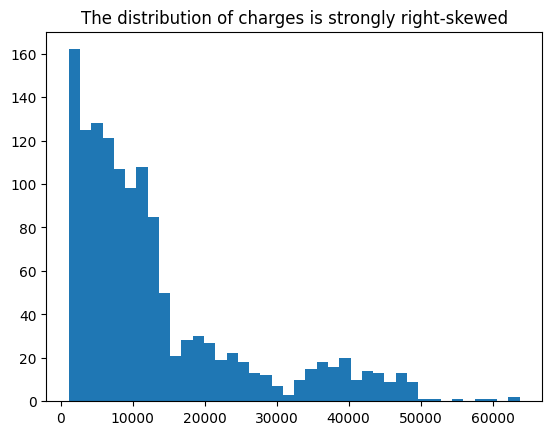

In [ ]:
url = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'
df_ins = pd.read_csv(url)

print('charges: min=%.0f max=%.0f skew=%.2f' % (df_ins['charges'].min(), df_ins['charges'].max(), df_ins['charges'].skew()))
print()
print('Mean charges by smoking:')
print(df_ins.groupby('smoker')['charges'].mean().round(1))

plt.hist(df_ins['charges'], bins=40);
plt.title('The distribution of charges is strongly right-skewed');

A simple comparison of the means shows that smokers pay about 3.8 times more than non-smokers. This suggests in advance that the smoker feature should turn out to be one of the strongest factors of the model.

Let us encode the categorical features and train a Gamma GLM — however, doing so straight away will not work, there is a catch for us here. In statsmodels the Gamma family uses the inverse link by default, not the logarithmic one.

Formally, as you read above, both link functions are admissible, but that by no means implies that they suit any data equally well. So to get hands-on with this, let us build two models at once: one with the default settings and the other with an explicitly specified log link.

In [ ]:
df_enc = pd.get_dummies(df_ins, columns=['sex', 'smoker', 'region'], drop_first=True)
X_ins = df_enc.drop(columns=['charges']).astype(float)
y_ins = df_enc['charges']

Xi_train, Xi_test, yi_train, yi_test = train_test_split(X_ins, y_ins, test_size=0.25, random_state=42)

from sklearn.metrics import r2_score, mean_squared_error

Xi_train_c = sm.add_constant(Xi_train)
Xi_test_c = sm.add_constant(Xi_test)

# WITHOUT an explicit link -- the default inverse link
model_wrong = sm.GLM(yi_train, Xi_train_c, family=sm.families.Gamma())
res_wrong = model_wrong.fit()
pred_wrong = res_wrong.predict(Xi_test_c)

# WITH an explicit log link -- correct
model_right = sm.GLM(yi_train, Xi_train_c, family=sm.families.Gamma(link=sm.families.links.Log()))
res_right = model_right.fit()
pred_right = res_right.predict(Xi_test_c)

print('Gamma, inverse link: R2=%.4f' % r2_score(yi_test, pred_wrong))
print('Gamma, log-link:         R2=%.4f' % r2_score(yi_test, pred_right))

Gamma, inverse link: R2=-239.4237
Gamma, log-link:         R2=0.6491


**Conclusion:** with the inverse link $R^2\approx-239$ — that is, the model turned out to be far worse than predicting a single mean value (a negative $R^2$ means "worse than a constant").

For this distribution the use of `inverse` ($\frac{1}{\mu}$) as the link function is not correct. After the transformation all the large values are squeezed almost to zero and the optimization of the model becomes unstable.


After switching to the logarithmic link we get $R^2\approx0.65$ — orders of magnitude better. Let us look at the coefficients. 

In [ ]:
effect = pd.DataFrame({
    'coef': res_right.params,
    'exp(coef)': np.exp(res_right.params),
    'p_value': res_right.pvalues,
}).round(4)
effect.sort_values('p_value')

,coef,exp(coef),p_value
const,7.4002,1636.3898,0.0000
age,0.0288,1.0292,0.0000
children,0.0762,1.0791,0.0000
smoker_yes,1.4972,4.4694,0.0000
bmi,0.0135,1.0136,0.0003
region_southwest,-0.1419,0.8677,0.0203
region_southeast,-0.1187,0.8880,0.0552
sex_male,-0.0568,0.9448,0.1855
region_northwest,-0.0552,0.9463,0.3645


Thanks to the same link function they can be interpreted the same way we did it in Poisson regression.

But as we saw earlier, the quality of a prediction does not mean the model can be fully trusted. Here too it holds that Gamma regression has its own assumptions about the distribution of the response and the character of the residuals. Namely:

* the target variable must be strictly positive;
* its distribution must be close to a Gamma distribution;
* the variance must grow together with the mean (in Gamma this is a natural property of the distribution);
* the relation between the features and the expectation must be correctly described by the chosen link function (we saw this with our own eyes).

In our case all the insurance payouts are positive, and the right-hand skew makes Gamma a natural candidate. The remaining assumptions, however, are better not taken on faith but checked with model diagnostics.

For now we will concentrate on how the model is built and on the interpretation of the coefficients, and we will cover lessons on detailed GLM diagnostics separately.

## Block 4. GAM — the solution when a single number per feature is not enough

All the models we have considered keep one important limitation — we assume that the influence of every feature does not depend on the others. For example, the coefficient at bmi is taken to be the same for smokers and non-smokers.

But does an extra kilogram of weight really affect the costs of both groups equally?
To work in such cases, as we know, one can move to a GAM (Generalized Additive Model). In it we:

* still model the conditional expectation;
* can choose the distribution of the target variable;
* use a link function g

but instead of one coefficient per feature we let the model pick a separate smooth function for it. The general form of a GAM:

$$g(\mathbb{E}[Y|X]) = \beta_0 + f_1(x_1) + f_2(x_2) + \dots + f_m(x_m)$$

That is, from the question about coefficients:
- By how much does the linear predictor change when the feature increases by one unit?

we move to:
- How does the linear predictor change overall at different values of the feature?

Let us see how this works in practice.

## pyGAM

The standard library for GAMs is `pyGAM`. In it the structure of a model is set with **terms** — separate components of the formula. The main ones are `s, l, f, te`, where:

- `l()` — a linear term
    `l(0)` — the linear effect of the first column: $\beta_1x_1$.
- `s()` — a smooth term
    s(0) — a smooth (nonlinear but differentiable) function for the first column: $f_1(x_1)$.
- `f()` — a categorical term
    f(2) — means that the third column is treated as a categorical feature and the model under the hood estimates a separate contribution for every category.
- `te()` — the joint effect of several features
    te(0, 1) builds a smooth function of two features at once: $f_{1,2}(x_1,x_2)$.

Let us assemble the first model using smooth and categorical terms.

In [ ]:
from pygam import LinearGAM, s, f, te
from sklearn.linear_model import LinearRegression

lr_ins = LinearRegression().fit(Xi_train, yi_train)
pred_lr_ins = lr_ins.predict(Xi_test)
print('Linear Regression: R2=%.4f' % r2_score(yi_test, pred_lr_ins))

cols = list(Xi_train.columns)
print(cols)

# s() -- a smooth function for the continuous ones (age, bmi), 
# f() -- a categorical term for the binary/discrete ones

gam_add = LinearGAM(s(0) + s(1) + f(2) + f(3) + f(4) + f(5) + f(6) + f(7))
gam_add.gridsearch(Xi_train.values, yi_train.values, lam=np.logspace(-2, 3, 15), progress=False)
pred_add = gam_add.predict(Xi_test)
print('GAM additive (age, bmi smooth): R2=%.4f' % r2_score(yi_test, pred_add))

Linear Regression: R2=0.7673
['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


GAM additive (age, bmi smooth): R2=0.7602


**Conclusion:**

The GAM variant we built is purely additive in every feature. It has the form where the prediction is a sum of partial effects:

$$\hat y = \beta_0 +f_{\text{age}}(\text{age}) +f_{\text{bmi}}(\text{bmi})
+\dots$$



Note that ($R^2\approx0.760$) barely differs from an ordinary linear regression ($R^2\approx0.767$). So moving from coefficients to functions may in itself give nothing (while we lose, in a certain sense, the simplicity of interpretation).

However, additivity in every feature may not be enough, features can interact, and when we have hypotheses we can take that into account. Let us add an explicit interaction term `te(bmi, smoker)` (smoothing over two features at once).

In [ ]:
gam_inter = LinearGAM(s(0) + te(1, 4) + f(2) + f(3) + f(5) + f(6) + f(7))
gam_inter.gridsearch(Xi_train.values, yi_train.values, lam=np.logspace(-2, 3, 10), progress=False)
pred_inter = gam_inter.predict(Xi_test)
print('GAM + te(bmi, smoker):                R2=%.4f' % r2_score(yi_test, pred_inter))

GAM + te(bmi, smoker):                R2=0.8704


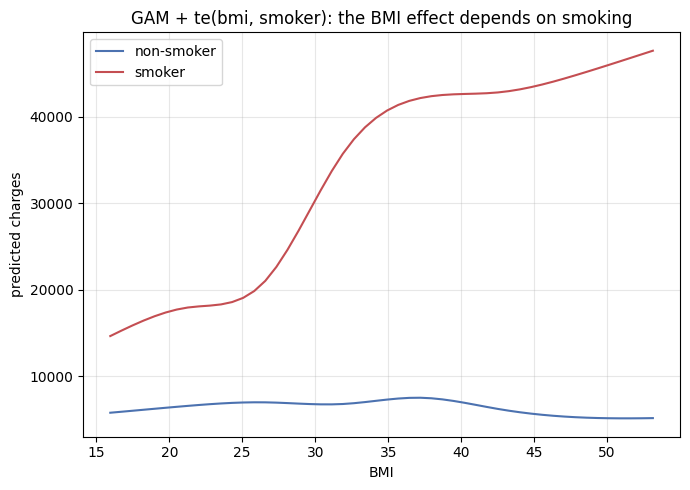

In [ ]:
base = Xi_train.median()
bmi_grid = np.linspace(Xi_train['bmi'].min(), Xi_train['bmi'].max(), 50)

def make_grid(smoker_val):
    grid = pd.DataFrame([base.values] * len(bmi_grid), columns=cols)
    grid['bmi'] = bmi_grid
    grid['smoker_yes'] = smoker_val
    return grid

pred_nonsmoker = gam_inter.predict(make_grid(0).values)
pred_smoker = gam_inter.predict(make_grid(1).values)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(bmi_grid, pred_nonsmoker, label='non-smoker', color='#4C72B0')
ax.plot(bmi_grid, pred_smoker, label='smoker', color='#C44E52')
ax.set_xlabel('BMI'); ax.set_ylabel('predicted charges')
ax.set_title('GAM + te(bmi, smoker): the BMI effect depends on smoking')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Conclusion:**

The explicit interaction term raised the quality from $R^2\approx0.760$ to $R^2\approx0.870$. The plot gives us the grounds — for **non-smokers** the prediction barely depends on BMI (5785 at BMI=16, 5162 at BMI=53 — a flat line). For **smokers** the prediction grows threefold (14649 $\to$ 47642), and it accelerates noticeably from about BMI$\approx$30 — which is exactly the clinical threshold of obesity. A GLM, or a GAM with smooth terms only, did not capture this.


Let us take away the note that the flexibility of the shape of a single feature may add almost nothing — and from the point of view of interpretability, with such a result it is better to stay with a linear model. Hypotheses about interactions found during EDA can help build a model that is more controllable than using more complex algorithms. 

## Block 5. GAMI-Net — generalizing systematic interaction

In Block 4 we manually added the interaction `te(bmi, smoker)`, based on our knowledge of the data. And of course we may not always have that knowledge — there may be too many features, or the features may be hard to analyse meaningfully. An exhaustive search over all pairs as a solution is not always possible.

Hence it is sometimes useful to move to automation and use the GAMI-Net we studied. It automates the search for interactions and has the form:

$$g(\mathbb{E}[y|x]) = \mu + \sum_{j \in S_1} h_j(x_j) + \sum_{(j,k)\in S_2} f_{jk}(x_j, x_k)$$

Every $h_j$ is its own small neural network (a main effect), every $f_{jk}$ is its own network on a pair of features (an interaction).

In the GAMI-Net of the [paper](https://arxiv.org/pdf/2003.07132), training goes in 3 stages with constraints (sparsity, heredity, **marginal clarity** — the orthogonality $\int h_jf_{jk}\,dF\approx0$, so that the main effect and the interaction do not "get confused").

We will go in two steps:
1. We will assemble a simplified version — without those constraints — and see what is lost without them.
2. We will assemble a version close to the [original](https://github.com/SelfExplainML/GamiNet/blob/master/gaminet/gaminet.py) one and compare it with a statistical GAM.

Let us start with the simplified one. 

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class MainEffectNetwork(nn.Module):
    # a neural network for the main effect of one feature
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(1, 10), nn.ReLU(), nn.Linear(10, 10), nn.ReLU(), nn.Linear(10, 1))
    def forward(self, x):
        return self.net(x)

class InteractionNetwork(nn.Module):
    # a neural network for the interaction of two features
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(2, 20), nn.ReLU(), nn.Linear(20, 10), nn.ReLU(), nn.Linear(10, 1))
    def forward(self, x):
        return self.net(x)

class SimpleGAMINet(nn.Module):
    # y = intercept + sum_i h_i(x_i) + f(x_0, x_1)
    def __init__(self, n_features):
        super().__init__()
        self.n_features = n_features
        self.main_effects = nn.ModuleList([MainEffectNetwork() for _ in range(n_features)])
        self.interaction = InteractionNetwork()
        self.intercept = nn.Parameter(torch.zeros(1))

    def components(self, x):
        # h_j separately and f_inter separately -- needed to compute marginal clarity (Omega) and for stage 2 (training on the residual)
        h = [self.main_effects[i](x[:, i:i+1]).squeeze(1) for i in range(self.n_features)]
        f_inter = self.interaction(x[:, :2]).squeeze(1)
        return h, f_inter

    def forward(self, x):
        h, f_inter = self.components(x)
        out = self.intercept.expand(x.shape[0])
        for hi in h:
            out = out + hi
        return out + f_inter

To control the success of training a bit more explicitly than by the loss, let us generate synthetic data with **known** effects:

- two main effects (linear in $x_0$, nonlinear $\sin$ in $x_1$),
- one interaction $(x_0,x_1)$,
- two "noise" features $x_2,x_3$ with no effect

and train the model on them. 

Epoch 100, Loss: 0.5842
Epoch 200, Loss: 0.2508
Epoch 300, Loss: 0.2388


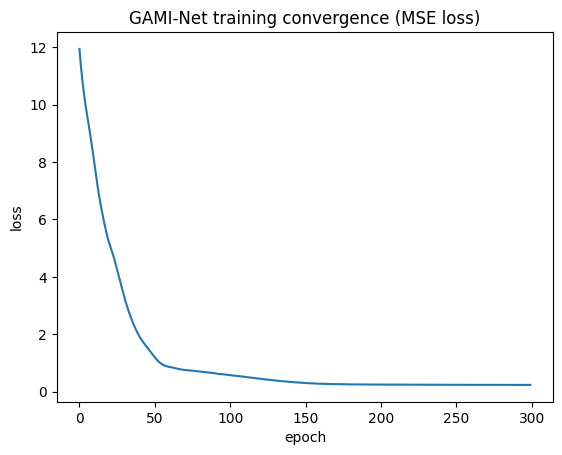

In [ ]:
np.random.seed(42)
torch.manual_seed(42)

n_samples, n_features = 1000, 4
X_gami = np.random.randn(n_samples, n_features)
y_gami = (
    2.0 * X_gami[:, 0]                    # main effect 1 (linear)
    + 3.0 * np.sin(2.0 * X_gami[:, 1])    # main effect 2 (nonlinear)
    + 1.5 * X_gami[:, 0] * X_gami[:, 1]   # interaction(0,1)
    + 0.5 * np.random.randn(n_samples)    # noise
)

Xg_train, Xg_test, yg_train, yg_test = train_test_split(X_gami, y_gami, test_size=0.3, random_state=42)
Xg_train_t = torch.tensor(Xg_train, dtype=torch.float32)
yg_train_t = torch.tensor(yg_train, dtype=torch.float32)
Xg_test_t = torch.tensor(Xg_test, dtype=torch.float32)

gami_model = SimpleGAMINet(n_features=n_features)
optimizer = optim.Adam(gami_model.parameters(), lr=0.01)
criterion = nn.MSELoss()

losses = []
gami_model.train()
for epoch in range(300):
    optimizer.zero_grad()
    preds = gami_model(Xg_train_t)
    loss = criterion(preds, yg_train_t)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch+1:3d}, Loss: {loss.item():.4f}')

plt.plot(losses);
plt.title('GAMI-Net training convergence (MSE loss)');
plt.xlabel('epoch'); plt.ylabel('loss');

In [ ]:
gami_model.eval()
with torch.no_grad():
    yg_pred_gami = gami_model(Xg_test_t).cpu().numpy()

print('GAMI-Net:               R2=%.4f  MSE=%.4f' % (r2_score(yg_test, yg_pred_gami), mean_squared_error(yg_test, yg_pred_gami)))

gam_baseline = LinearGAM(s(0) + s(1)  + s(2) + s(3)).fit(Xg_train, yg_train)
gam_gt_interaction_baseline = LinearGAM(s(0) + s(1) + te(0, 1) + s(2) + s(3)).fit(Xg_train, yg_train)

yg_pred_gam = gam_baseline.predict(Xg_test)
yg_pred_gam_interaction = gam_gt_interaction_baseline.predict(Xg_test)

print('GAM without interactions: R2=%.4f  MSE=%.4f' % (r2_score(yg_test, yg_pred_gam), mean_squared_error(yg_test, yg_pred_gam)))
print('GAM with the true interaction: R2=%.4f  MSE=%.4f' % (r2_score(yg_test, yg_pred_gam_interaction), mean_squared_error(yg_test, yg_pred_gam_interaction)))

GAMI-Net:               R2=0.9627  MSE=0.4199


GAM without interactions: R2=0.7515  MSE=2.7939
GAM with the true interaction: R2=0.9764  MSE=0.2656


GAMI-Net (with the interaction network) gives $R^2\approx0.963$, a GAM without an interaction on this synthetic task gives $R^2\approx0.752$, and a GAM with an interaction gives $R^2\approx0.9762$.

We got a gain **related to the interactions**, but not related to solving the task by gradient descent and a neural-network approach. Let us try to beat the statistical GAM by implementing a training pipeline that repeats the paper almost entirely. To do that we will need to carry out three stages:

1. **Main effects separately.** We train all the $h_j(x_j)$ on the full target, without the interaction network at all.
2. **The interaction on the residuals.** We freeze the main effects and train the interaction network not on $y$ but on the **residual** $y - \sum_jh_j(x_j)$ — that is, only on the part the main effects could not explain. By definition this nudges towards orthogonality, since the interaction network does not see what has already been explained.
3. **Joint fine-tuning.** We unfreeze everything and fine-tune together, now with the penalty $\Omega$, for polishing.

**The difference from the [official implementation](https://github.com/SelfExplainML/GamiNet)** in such a setup remains in the details — the selection of effects, the search for interaction candidates, monotonicity constraints, early stopping on validation. We have none of that: on synthetic data with 2 known effects there is nothing to select, but you can look at the implementation code via the link above.

In [ ]:
def evaluate(model):
    model.eval()
    with torch.no_grad():
        y_pred = model(Xg_test_t).numpy()
    r2 = r2_score(yg_test, y_pred)

    grid = torch.linspace(-3, 3, 100).unsqueeze(1)
    with torch.no_grad():
        h0 = model.main_effects[0](grid).squeeze().numpy()
        h1 = model.main_effects[1](grid).squeeze().numpy()
    x_np = grid.squeeze().numpy()
    true_h0 = 2.0 * x_np
    true_h1 = 3.0 * np.sin(2.0 * x_np)
    corr0 = np.corrcoef(h0 - h0.mean(), true_h0 - true_h0.mean())[0, 1]
    corr1 = np.corrcoef(h1 - h1.mean(), true_h1 - true_h1.mean())[0, 1]
    return r2, corr0, corr1

In [ ]:
def train_gami_staged(epochs_stage1=300, epochs_stage2=300, epochs_stage3=200, lam=1.0, seed=42):
    torch.manual_seed(seed)
    model = SimpleGAMINet(n_features=n_features)
    criterion = nn.MSELoss()

    # --- Stage 1: main effects only (the interaction does not take part in the prediction) ---
    params_stage1 = list(model.main_effects.parameters()) + [model.intercept]
    opt1 = optim.Adam(params_stage1, lr=0.01)
    for epoch in range(epochs_stage1):
        opt1.zero_grad()
        h, _ = model.components(Xg_train_t)
        pred = model.intercept.expand(Xg_train_t.shape[0])
        for hi in h:
            pred = pred + hi
        loss = criterion(pred, yg_train_t)
        loss.backward()
        opt1.step()

    # --- Stage 2: freeze the main effects, train the interaction on the residual ---
    for p in model.main_effects.parameters():
        p.requires_grad_(False)
    with torch.no_grad():
        h, _ = model.components(Xg_train_t)
        pred_stage1 = model.intercept.expand(Xg_train_t.shape[0]).clone()
        for hi in h:
            pred_stage1 = pred_stage1 + hi
        residual_stage1 = yg_train_t - pred_stage1

    opt2 = optim.Adam(model.interaction.parameters(), lr=0.01)
    for epoch in range(epochs_stage2):
        opt2.zero_grad()
        f_inter = model.interaction(Xg_train_t[:, :2]).squeeze(1)
        loss = criterion(f_inter, residual_stage1)
        loss.backward()
        opt2.step()

    # --- Stage 3: joint fine-tuning. In the official GAMI-Net there are two separate
    # gradients (two "tapes"): the main effects are updated by pure MSE, the interaction --
    # by MSE + Omega. We used to have one shared backward(mse + lam*omega) over all
    # the parameters at once -- because of that Omega could slightly "pull" the already decent
    # trained h_0. We separate the gradients the same way as in the original.
    for p in model.main_effects.parameters():
        p.requires_grad_(True)

    main_params = list(model.main_effects.parameters()) + [model.intercept]
    inter_params = list(model.interaction.parameters())
    opt_main = optim.Adam(main_params, lr=0.001)
    opt_inter = optim.Adam(inter_params, lr=0.001)

    for epoch in range(epochs_stage3):
        h, f_inter = model.components(Xg_train_t)
        pred = model.intercept.expand(Xg_train_t.shape[0])
        for hi in h:
            pred = pred + hi
        pred = pred + f_inter
        mse = criterion(pred, yg_train_t)
        omega = torch.abs((h[0] * f_inter).mean()) + torch.abs((h[1] * f_inter).mean())

        opt_main.zero_grad()
        opt_inter.zero_grad()

        # the main effects see only mse -- Omega does not touch them
        grads_main = torch.autograd.grad(mse, main_params, retain_graph=True)
        # the interaction sees mse + the penalty for non-orthogonality
        grads_inter = torch.autograd.grad(mse + lam * omega, inter_params, retain_graph=False)

        for p, g in zip(main_params, grads_main):
            p.grad = g
        for p, g in zip(inter_params, grads_inter):
            p.grad = g

        opt_main.step()
        opt_inter.step()

    return model

In [ ]:
model_staged = train_gami_staged()

r2_st, c0_st, c1_st = evaluate(model_staged)
print('Three-stage procedure:   R2=%.4f  corr_h0=%.4f  corr_h1=%.4f' % (r2_st, c0_st, c1_st))

r2, c0, c1 = evaluate(gami_model)
print('Baseline implementation:   R2=%.4f  corr_h0=%.4f  corr_h1=%.4f' % (r2, c0, c1))

Three-stage procedure:   R2=0.9620  corr_h0=0.9977  corr_h1=0.8463
Baseline implementation:   R2=0.9627  corr_h0=0.9992  corr_h1=0.4757


The quality did not improve much, but the structure did — the three-stage procedure gives a correlation $h_1\approx0.845$, better than the original $\approx0.48$ without orthogonality. At the same time $h_0$ stays excellent ($\approx0.997$), and $R^2\approx0.962$ is on a par with the best of the previous version.

Let us look at the correlations of the learned dependencies for the baseline GAMs, and then at the learned dependencies themselves with our own eyes, and compare:
- the learned functions with the true ones (up to an additive constant — it goes into the intercept)
- the models with each other

In [ ]:
# gammi-net variatns
grid = torch.linspace(-3, 3, 100).unsqueeze(1)

# baseline
gami_model.eval()

with torch.no_grad():
    h0 = gami_model.main_effects[0](grid).squeeze().numpy()
    h1 = gami_model.main_effects[1](grid).squeeze().numpy()

# staged 
model_staged.eval()
with torch.no_grad():
    h0_staged = model_staged.main_effects[0](grid).squeeze().numpy()
    h1_staged = model_staged.main_effects[1](grid).squeeze().numpy()

In [ ]:
def shape_corr(model, term_idx, true_fn, label):
    XX = model.generate_X_grid(term=term_idx)
    pdep = model.partial_dependence(term=term_idx, X=XX)
    raw = XX[:, term_idx]
    true_vals = true_fn(raw)
    corr = np.corrcoef(pdep - pdep.mean(), true_vals - true_vals.mean())[0, 1]
    print(f'{label}: corr(pyGAM shape, true function) = {corr:.4f}')
    return corr, raw, pdep

true_h0 = lambda x: 2.0 * x
true_h1 = lambda x: 3.0 * np.sin(2.0 * x)

print('--- GAM without interactions (knows nothing about the interaction at all) ---')
corr_base_x0, raw_base_x0, pdep_base_x0 = shape_corr(gam_baseline, 0, true_h0, 'x0')
corr_base_x1, raw_base_x1, pdep_base_x1 = shape_corr(gam_baseline, 1, true_h1, 'x1')

print('--- GAM with the true te(0,1) (knows what interacts with what) ---')
corr_gt_x0, raw_gt_x0, pdep_gt_x0 = shape_corr(gam_gt_interaction_baseline, 0, true_h0, 'x0')
corr_gt_x1, raw_gt_x1, pdep_gt_x1 = shape_corr(gam_gt_interaction_baseline, 1, true_h1, 'x1')

--- GAM without interactions (knows nothing about the interaction at all) ---
x0: corr(pyGAM shape, true function) = 0.9633
x1: corr(pyGAM shape, true function) = 0.9376
--- GAM with the true te(0,1) (knows what interacts with what) ---
x0: corr(pyGAM shape, true function) = 0.9997
x1: corr(pyGAM shape, true function) = 0.9891


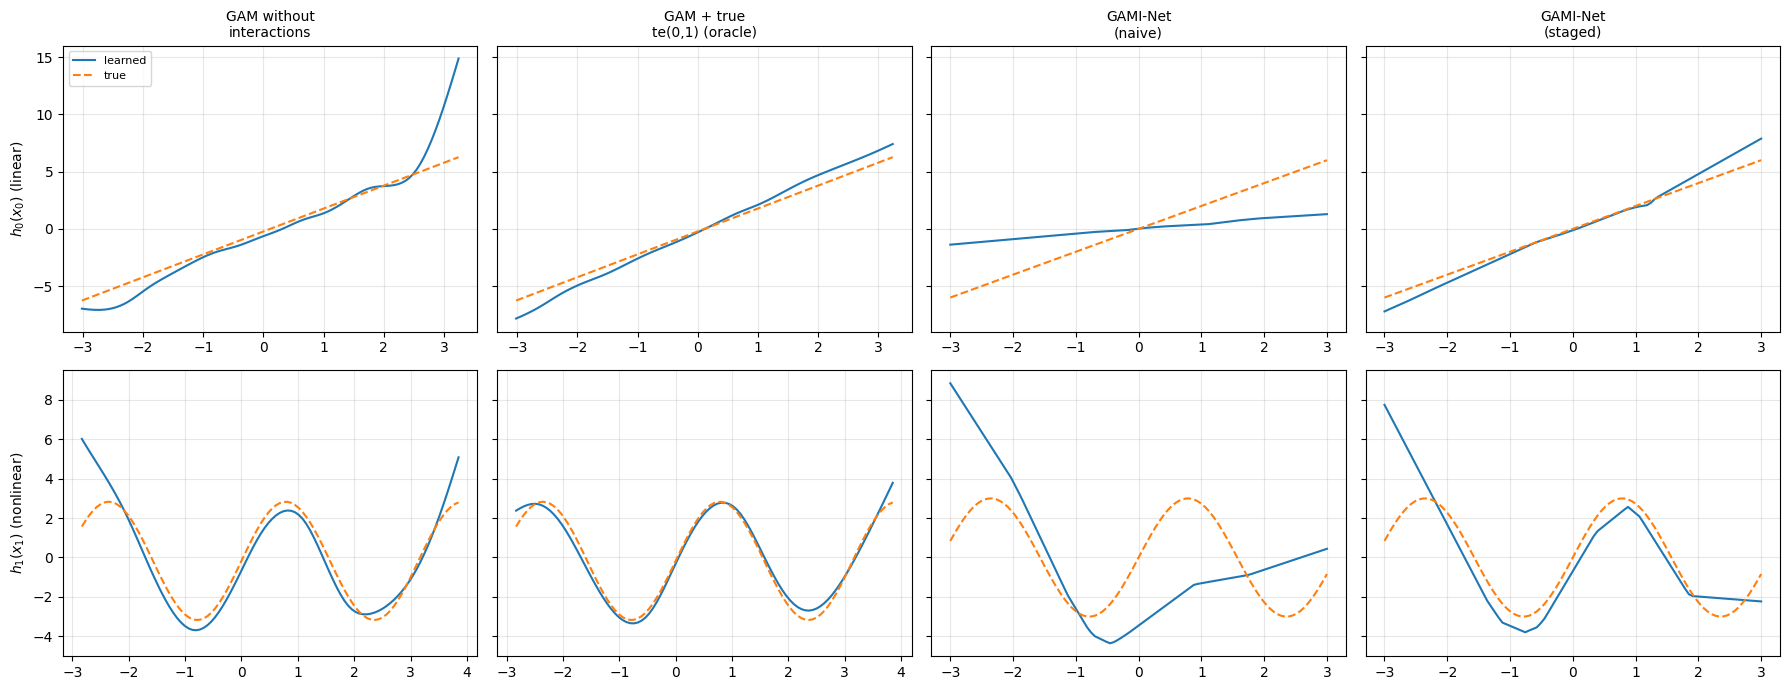

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7), sharey='row')
# gt
x_np = grid.squeeze().numpy()

columns = [
    ('GAM without\ninteractions', (raw_base_x0, pdep_base_x0), (raw_base_x1, pdep_base_x1)),
    ('GAM + true\nte(0,1) (oracle)', (raw_gt_x0, pdep_gt_x0), (raw_gt_x1, pdep_gt_x1)),
    ('GAMI-Net\n(naive)', (x_np, h0), (x_np, h1)),
    ('GAMI-Net\n(staged)', (x_np, h0_staged), (x_np, h1_staged)),
]

for col_idx, (title, (rx0, px0), (rx1, px1)) in enumerate(columns):
    ax0 = axes[0, col_idx]
    ax0.plot(rx0, px0 - px0.mean(), label='learned')
    ax0.plot(rx0, true_h0(rx0) - true_h0(rx0).mean(), '--', label='true')
    ax0.set_title(title, fontsize=10)
    ax0.grid(alpha=0.3)

    ax1 = axes[1, col_idx]
    ax1.plot(rx1, px1 - px1.mean(), label='learned')
    ax1.plot(rx1, true_h1(rx1) - true_h1(rx1).mean(), '--', label='true')
    ax1.grid(alpha=0.3)

axes[0, 0].set_ylabel('$h_0(x_0)$ (linear)')
axes[1, 0].set_ylabel('$h_1(x_1)$ (nonlinear)')
axes[0, 0].legend(fontsize=8)
plt.tight_layout()
plt.show()

**Summary of the results:**

| Model | $R^2$ | corr($h_0$) | corr($h_1$) |
|---|---|---|---|
| GAM without interactions (pyGAM) | $0.752$ | $0.963$ | $0.938$ |
| GAM with the true `te(0,1)` (pyGAM) | $0.976$ | $1.000$ | $0.989$ |
| GAMI-Net, naive joint training | $0.964$ | $0.998$ | $0.483$ |
| GAMI-Net, three-stage procedure | $0.962$ | $0.998$ | $0.847$ |

- The best result is shown by pyGAM with the given interaction;
- All the models except the naive GAMI-Net implementation recover the linear $h_0$ almost perfectly;
- The nonlinear $h_1$, the sinusoid, is correctly reproduced only by the classic GAM models;
- Staged training for GAMI-Net helps the model learn a more correct structure of the dependence;


**Why is that?**

We considered a synthetic task where, with known dependencies, the training mechanism inside `pyGAM` outruns gradient descent. That will not always be the case. For `pyGAM` every $s(\cdot)$ term is a penalized spline, which is estimated through a classic (penalized) regression over a batch of basis functions rather than converging to a solution through noisy gradient descent of several mutually influencing neural networks at once. The absence of noise means better training.


**The main takeaway here:** we saw that a high $R^2$ and an honest, reality-matching, unbiased component-wise decomposition are **different properties of a model**, and one does not guarantee the other. A statistically grounded procedure (penalized splines) can outrun a more flexible but less formally grounded neural-network implementation precisely in interpretability — the very quality for which GAMs and GAMI-Net are built at all. That is why, before adding complexity, one should always start from simpler methods. 

## Conclusion

We have gone through all 3 extensions on top of linear models. Let us highlight the most important points:

- **GLM** — the right distribution and the right link function give the right scale for interpreting $e^{\beta}$: odds for Bernoulli, IRR for Poisson, a multiplicative effect on the mean for Gamma. A wrong link (Block 3: $R^2\approx-239\to0.65$) or a wrong distribution (Block 2: overdispersion) lead to variable quality and incorrect conclusions — all of which can produce false-positive/false-negative results.

- **GAM** — a flexible model that allows moving from a number $\beta_j$ to a function $f_j(x_j)$. But (Block 4) a functional dependence is not a universal solution. And here GAMs are still capable of giving a strong gain — with the correct addition of interaction terms.

- **GAMI-Net** — helps to win on the need to put forward hypotheses about relations, but can give unstable structures that are not quite close to the original dependencies. The constraints of the model and the structure of training matter here, so that the decomposition comes as close to reality as possible rather than just "predicting well in total".

In all three cases we pay for the flexibility of the model — every time it takes more time and more nuances taken into account to interpret the model correctly. But we win in that **within the trained model** the prediction always decomposes into contributions.

Thank you for studying the material! You are ready to move on to new lessons =)